# So sánh AOD AERONET vs MODIS MCD19A2 (4 window versions: center / 3x3 / 5x5 / 10x10)

**Tiêu chí collocation (Petrenko-Ichoku, áp dụng cho MODIS polar-orbit):**

| Tham số | Giá trị | Lý do |
|---|---|---|
| Spatial window | center 1×1, 3×3, 5×5, 10×10 pixel quanh trạm | So sánh ảnh hưởng của bán kính tổng hợp |
| Temporal window | **±30 phút** quanh thời điểm vệ tinh | Terra + Aqua polar-orbit |
| Bước sóng | **550 nm** | MCD19A2 `Optical_Depth_055`; AERONET interp 550 nm |
| Min satellite pixels (3x3/5x5/10x10) | **≥ 2** (`n_valid_*`) | Petrenko |
| Min AERONET obs | **≥ 2** | Tránh đo lỗi |
| CoV satellite (3x3/5x5/10x10) | **< 0.5** | `aod_std_* / aod_mean_*` |
| Center | không có std/n_pixel | dùng pixel duy nhất, không lọc CoV |

**Nguồn MODIS:** `/home/slow_data/Air_Quality/MODIS_MCD19A2/outputs/stations_aod_v5/{station}.csv`
— file đã trích sẵn 4 phiên bản: `aod_550_center`, `aod_550_mean_3x3`, `aod_550_mean_5x5`, `aod_550_mean_10x10`.

In [1]:
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import RANSACRegressor, LinearRegression

MODIS_ROOT = Path('/home/slow_data/Air_Quality/MODIS_MCD19A2/outputs/stations_aod_v5')
AER_ROOT   = Path('/home/slow_data/Air_Quality/AERONET/process/aod_550/10')

STATIONS = ['NGHIA_DO', 'Bac_Lieu']
VERSIONS = ['center', '3x3', '5x5', '10x10']   # 4 window sizes

DT_MIN  = 30    # ±30 phút (polar-orbit)
MIN_SAT = 2     # n_valid (chỉ áp với 3x3/5x5/10x10)
MIN_AER = 2
MAX_COV = 0.5

## 1. AERONET — lọc AOD 550 nm

In [2]:
def load_aeronet(station):
    df = pd.read_csv(AER_ROOT / f'{station}.csv', low_memory=False)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[['datetime', 'aod_550', 'ae']].rename(columns={'aod_550': 'aod550'})
    df = df[df['aod550'].between(0, 5)]
    return df.sort_values('datetime').reset_index(drop=True)

aer = {s: load_aeronet(s) for s in STATIONS}
for s, df in aer.items():
    print(f'{s}: {len(df):,} obs, {df.datetime.min()} -> {df.datetime.max()}')
aer['NGHIA_DO'].head(3)

NGHIA_DO: 13,279 obs, 2022-02-23 13:56:22 -> 2026-05-01 06:36:44
Bac_Lieu: 15,695 obs, 2022-04-21 06:38:46 -> 2025-08-22 10:16:10


,datetime,aod550,ae
0,2022-02-23 13:56:22,0.589588,1.316554
1,2022-02-23 14:01:22,0.601053,1.307935
2,2022-02-23 14:06:22,0.602714,1.292318


## 2. MODIS — đọc 4 phiên bản window quanh trạm

File `stations_aod_v5/*.csv` đã chứa sẵn 4 cách tổng hợp khoảng cách quanh trạm:
- `aod_550_center` — pixel trung tâm (1 ô).
- `aod_550_mean_3x3`, `aod_550_std_3x3`, `n_valid_3x3` — cửa sổ 3×3 pixel (~3 km×3).
- `aod_550_mean_5x5`, `aod_550_std_5x5`, `n_valid_5x5` — 5×5 (~5 km×5).
- `aod_550_mean_10x10`, `aod_550_std_10x10`, `n_valid_10x10` — 10×10 (~10 km×10).

Petrenko-style filter (`n ≥ 2`, `CoV < 0.5`) chỉ áp được cho 3 phiên bản mean. Center là một pixel nên giữ nguyên (không lọc CoV).

In [3]:
def load_modis_versions(station):
    """Return dict version -> DataFrame[ts, aod_mean, aod_std, n_valid].

    Center row uses (aod_550_center, std=NaN, n_valid=1) — no CoV filtering possible.
    Each version is filtered independently: drop rows where that version's AOD is NaN.
    """
    df = pd.read_csv(MODIS_ROOT / f'{station}.csv', low_memory=False)
    df['ts'] = pd.to_datetime(df['timestamp'])
    out = {}
    for v in VERSIONS:
        if v == 'center':
            sub = pd.DataFrame({
                'ts':       df['ts'],
                'aod_mean': df['aod_550_center'],
                'aod_std':  np.nan,
                'n_valid':  1,
            })
        else:
            sub = pd.DataFrame({
                'ts':       df['ts'],
                'aod_mean': df[f'aod_550_mean_{v}'],
                'aod_std':  df[f'aod_550_std_{v}'],
                'n_valid':  df[f'n_valid_{v}'],
            })
        sub = sub.dropna(subset=['aod_mean'])
        sub = sub[sub['aod_mean'].between(0, 5)]
        out[v] = sub.sort_values('ts').reset_index(drop=True)
    return out

modis = {s: load_modis_versions(s) for s in STATIONS}
for s, by_v in modis.items():
    counts = {v: len(by_v[v]) for v in VERSIONS}
    span   = (by_v['10x10']['ts'].min(), by_v['10x10']['ts'].max())
    print(f'{s}: {counts}  | span {span[0]} -> {span[1]}')
modis['NGHIA_DO']['5x5'].head(3)

NGHIA_DO: {'center': 287, '3x3': 366, '5x5': 445, '10x10': 580}  | span 2022-01-04 11:05:00 -> 2026-06-01 08:55:00
Bac_Lieu: {'center': 263, '3x3': 472, '5x5': 630, '10x10': 854}  | span 2022-01-01 10:40:00 -> 2026-05-26 08:20:00


,ts,aod_mean,aod_std,n_valid
0,2022-01-04 11:05:00,0.685875,0.050469,8
1,2022-01-18 11:15:00,0.282571,0.009179,21
2,2022-01-18 12:55:00,0.219000,0.023208,20


## 3. Collocation theo từng phiên bản

Với mỗi overpass MODIS hợp lệ:
- 3x3 / 5x5 / 10x10: yêu cầu `n_valid ≥ 2` và `CoV < 0.5`.
- center: bỏ qua filter pixel (1 ô) → chỉ cần AOD hợp lệ.
- Tìm AERONET trong **±30 phút** quanh `ts`, ≥ 2 đo → mean.

In [4]:
def collocate(station, version, df_aer, df_m):
    """Petrenko-style collocation for one MODIS window version."""
    df_h = df_m.copy()
    if version == 'center':
        df_h['cov'] = np.nan
    else:
        df_h['cov'] = df_h['aod_std'] / df_h['aod_mean'].replace(0, np.nan)
        df_h = df_h[(df_h['n_valid'] >= MIN_SAT) & (df_h['cov'] < MAX_COV)]

    a_times = df_aer['datetime'].values.astype('datetime64[ns]')
    a_vals  = df_aer['aod550'].values
    dt_ns   = np.timedelta64(DT_MIN, 'm')

    rows = []
    for _, r in df_h.iterrows():
        ts = np.datetime64(r['ts'])
        mask = (a_times >= ts - dt_ns) & (a_times <= ts + dt_ns)
        if mask.sum() < MIN_AER:
            continue
        sub = a_vals[mask]
        rows.append({
            'station':  station,
            'version':  version,
            'ts':       r['ts'],
            'aer_mean': float(sub.mean()),
            'aer_std':  float(sub.std(ddof=0)),
            'aer_n':    int(mask.sum()),
            'sat_mean': float(r['aod_mean']),
            'sat_std':  float(r['aod_std']) if pd.notna(r['aod_std']) else np.nan,
            'sat_cov':  float(r['cov']) if pd.notna(r['cov']) else np.nan,
            'sat_n':    int(r['n_valid']) if pd.notna(r['n_valid']) else 1,
        })
    return pd.DataFrame(rows)

In [5]:
pairs = pd.concat(
    [collocate(s, v, aer[s], modis[s][v]) for s in STATIONS for v in VERSIONS],
    ignore_index=True,
)
print(f'Total pairs: {len(pairs):,}')
print(pairs.groupby(['station', 'version']).size().unstack(fill_value=0).reindex(columns=VERSIONS))
pairs.head()

Total pairs: 1,687
version   center  3x3  5x5  10x10
station                          
Bac_Lieu     158  203  246    311
NGHIA_DO     164  169  201    235


,station,version,ts,aer_mean,aer_std,aer_n,sat_mean,sat_std,sat_cov,sat_n
0,NGHIA_DO,center,2022-02-24 09:55:00,0.501040,0.017543,7,0.527,NaN,NaN,1
1,NGHIA_DO,center,2022-02-25 10:35:00,0.974137,0.041745,8,0.809,NaN,NaN,1
2,NGHIA_DO,center,2022-03-08 13:35:00,0.361885,0.028649,10,0.180,NaN,NaN,1
3,NGHIA_DO,center,2022-03-26 13:25:00,0.774892,0.018397,8,0.426,NaN,NaN,1
4,NGHIA_DO,center,2022-04-03 10:55:00,0.302597,0.002695,10,0.124,NaN,NaN,1


## 4. Metrics theo (station, version)

- **R**: Pearson correlation
- **RMSE**, **MAE**, **MBE**
- **EE envelope** MODIS DT/DB: tỉ lệ điểm trong `±(0.05 + 0.15·AOD_AERONET)` (giữ cùng convention như VIIRS notebook).
- **OLS** + **RANSAC**.

In [6]:
def fit_ransac(x, y, seed=0):
    if len(x) < 3:
        return np.nan, np.nan, 0
    try:
        ransac = RANSACRegressor(
            estimator=LinearRegression(),
            min_samples=max(2, int(0.2 * len(x))),
            residual_threshold=None,
            random_state=seed,
        ).fit(x.reshape(-1, 1), y)
        slope     = float(ransac.estimator_.coef_[0])
        intercept = float(ransac.estimator_.intercept_)
        n_in      = int(ransac.inlier_mask_.sum())
        return slope, intercept, n_in
    except ValueError:
        return np.nan, np.nan, 0

def evaluate(df, sat_col='sat_mean'):
    sub = df.dropna(subset=['aer_mean', sat_col])
    x = sub['aer_mean'].values
    y = sub[sat_col].values
    n = len(sub)
    if n < 2:
        return {'N': n, 'R': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
                'MBE': np.nan, 'within_EE': np.nan,
                'slope': np.nan, 'intercept': np.nan,
                'slope_r': np.nan, 'intercept_r': np.nan, 'N_in': 0}
    r, _ = stats.pearsonr(x, y)
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    mae  = float(np.mean(np.abs(y - x)))
    mbe  = float(np.mean(y - x))
    ee   = 0.05 + 0.15 * x
    within_ee = float(np.mean((y - x >= -ee) & (y - x <= ee)))
    slope, intercept = np.polyfit(x, y, 1)
    slope_r, intercept_r, n_in = fit_ransac(x, y)
    return {'N': n, 'R': r, 'RMSE': rmse, 'MAE': mae, 'MBE': mbe,
            'within_EE': within_ee,
            'slope': float(slope), 'intercept': float(intercept),
            'slope_r': slope_r, 'intercept_r': intercept_r, 'N_in': n_in}

rows = []
for v in VERSIONS:
    sub_v = pairs[pairs['version'] == v]
    rows.append({'station': 'ALL', 'version': v, **evaluate(sub_v)})
    for s, grp in sub_v.groupby('station'):
        rows.append({'station': s, 'version': v, **evaluate(grp)})
metrics = pd.DataFrame(rows)
# Order rows for readability
metrics['station'] = pd.Categorical(metrics['station'], ['ALL'] + STATIONS)
metrics['version'] = pd.Categorical(metrics['version'], VERSIONS)
metrics = metrics.sort_values(['station', 'version']).reset_index(drop=True)
metrics.round(3)

,station,version,N,R,RMSE,MAE,MBE,within_EE,slope,intercept,slope_r,intercept_r,N_in
0,ALL,center,322,0.843,0.263,0.158,-0.109,0.516,0.593,0.064,0.746,0.024,216
1,ALL,3x3,372,0.882,0.251,0.147,-0.086,0.548,0.598,0.082,0.717,0.075,242
2,ALL,5x5,447,0.886,0.248,0.143,-0.073,0.559,0.585,0.098,0.733,0.069,287
3,ALL,10x10,546,0.907,0.242,0.142,-0.066,0.527,0.579,0.112,0.648,0.091,360
4,NGHIA_DO,center,164,0.841,0.342,0.213,-0.188,0.506,0.603,0.063,0.813,-0.001,122
5,NGHIA_DO,3x3,169,0.886,0.343,0.207,-0.185,0.527,0.610,0.078,0.730,0.025,127
6,NGHIA_DO,5x5,201,0.887,0.342,0.200,-0.180,0.587,0.600,0.090,0.714,0.051,152
7,NGHIA_DO,10x10,235,0.906,0.340,0.203,-0.182,0.553,0.591,0.103,0.704,0.053,183
8,Bac_Lieu,center,158,0.300,0.139,0.100,-0.026,0.525,0.276,0.126,0.807,0.043,88
9,Bac_Lieu,3x3,203,0.295,0.133,0.097,-0.003,0.567,0.255,0.150,0.429,0.094,110


### So sánh ngang theo phiên bản

Bảng pivot — cho ALL stations, R / RMSE / MBE / EE% / N theo từng window.

In [7]:
summary_all = metrics[metrics['station'] == 'ALL'].set_index('version')[
    ['N', 'R', 'RMSE', 'MAE', 'MBE', 'within_EE',
     'slope', 'intercept', 'slope_r', 'intercept_r', 'N_in']
]
summary_all.round(3)

,N,R,RMSE,MAE,MBE,within_EE,slope,intercept,slope_r,intercept_r,N_in
version,,,,,,,,,,,
center,322,0.843,0.263,0.158,-0.109,0.516,0.593,0.064,0.746,0.024,216
3x3,372,0.882,0.251,0.147,-0.086,0.548,0.598,0.082,0.717,0.075,242
5x5,447,0.886,0.248,0.143,-0.073,0.559,0.585,0.098,0.733,0.069,287
10x10,546,0.907,0.242,0.142,-0.066,0.527,0.579,0.112,0.648,0.091,360


## 5. Scatter + EE envelope (4 versions × 3 groups)

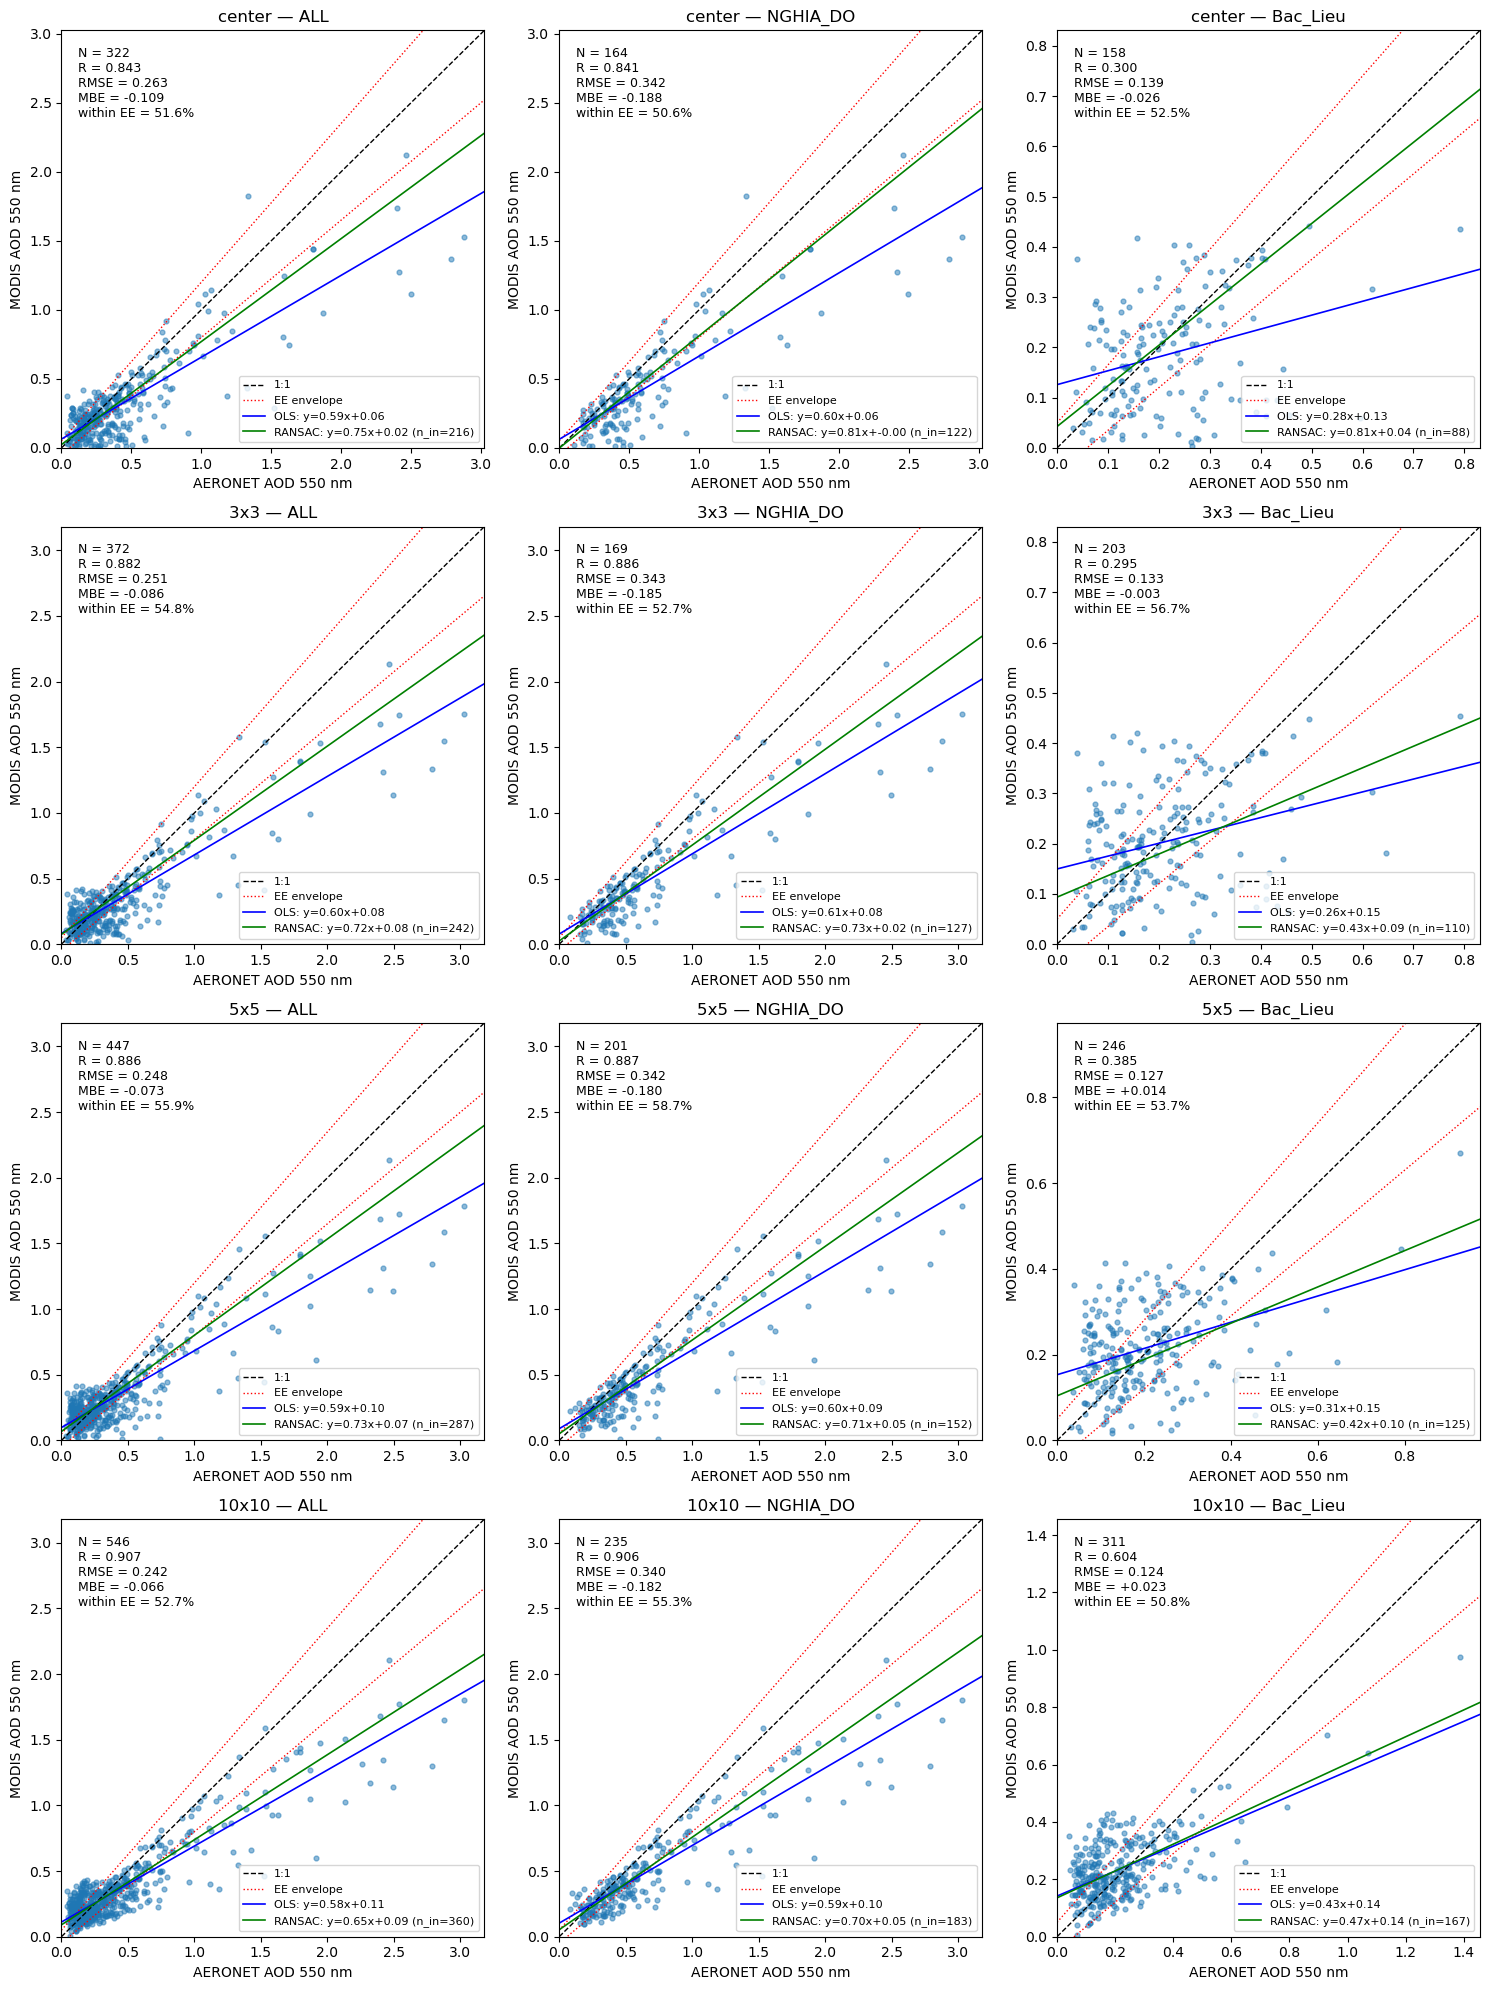

In [8]:
def plot_scatter(ax, df, label, sat_col='sat_mean'):
    sub = df.dropna(subset=['aer_mean', sat_col])
    if len(sub) == 0:
        ax.set_title(f'{label} - empty'); return
    x = sub['aer_mean'].values; y = sub[sat_col].values
    m = evaluate(sub, sat_col)
    ax.scatter(x, y, s=12, alpha=0.5)
    lim = max(x.max(), y.max(), 0.1) * 1.05
    grid = np.linspace(0, lim, 100)
    ax.plot(grid, grid, 'k--', lw=1, label='1:1')
    ax.plot(grid, grid + (0.05 + 0.15 * grid), 'r:', lw=1, label='EE envelope')
    ax.plot(grid, grid - (0.05 + 0.15 * grid), 'r:', lw=1)
    if np.isfinite(m['slope']):
        ax.plot(grid, m['slope'] * grid + m['intercept'], 'b-', lw=1.2,
                label=f"OLS: y={m['slope']:.2f}x+{m['intercept']:.2f}")
    if np.isfinite(m['slope_r']):
        ax.plot(grid, m['slope_r'] * grid + m['intercept_r'], 'g-', lw=1.2,
                label=f"RANSAC: y={m['slope_r']:.2f}x+{m['intercept_r']:.2f} (n_in={m['N_in']})")
    txt = (f"N = {m['N']}\nR = {m['R']:.3f}\nRMSE = {m['RMSE']:.3f}\n"
           f"MBE = {m['MBE']:+.3f}\nwithin EE = {m['within_EE']*100:.1f}%")
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('AERONET AOD 550 nm'); ax.set_ylabel('MODIS AOD 550 nm')
    ax.set_title(label); ax.legend(loc='lower right', fontsize=8)

groups = [('ALL', None)] + [(s, s) for s in STATIONS]
fig, axes = plt.subplots(len(VERSIONS), len(groups),
                         figsize=(5 * len(groups), 5 * len(VERSIONS)),
                         squeeze=False)
for i, v in enumerate(VERSIONS):
    for j, (g_label, g_station) in enumerate(groups):
        sub = pairs[pairs['version'] == v]
        if g_station is not None:
            sub = sub[sub['station'] == g_station]
        plot_scatter(axes[i, j], sub, f'{v} — {g_label}')
fig.tight_layout(); plt.show()

## 6. Bias theo AOD bin và theo giờ UTC — so sánh 4 phiên bản

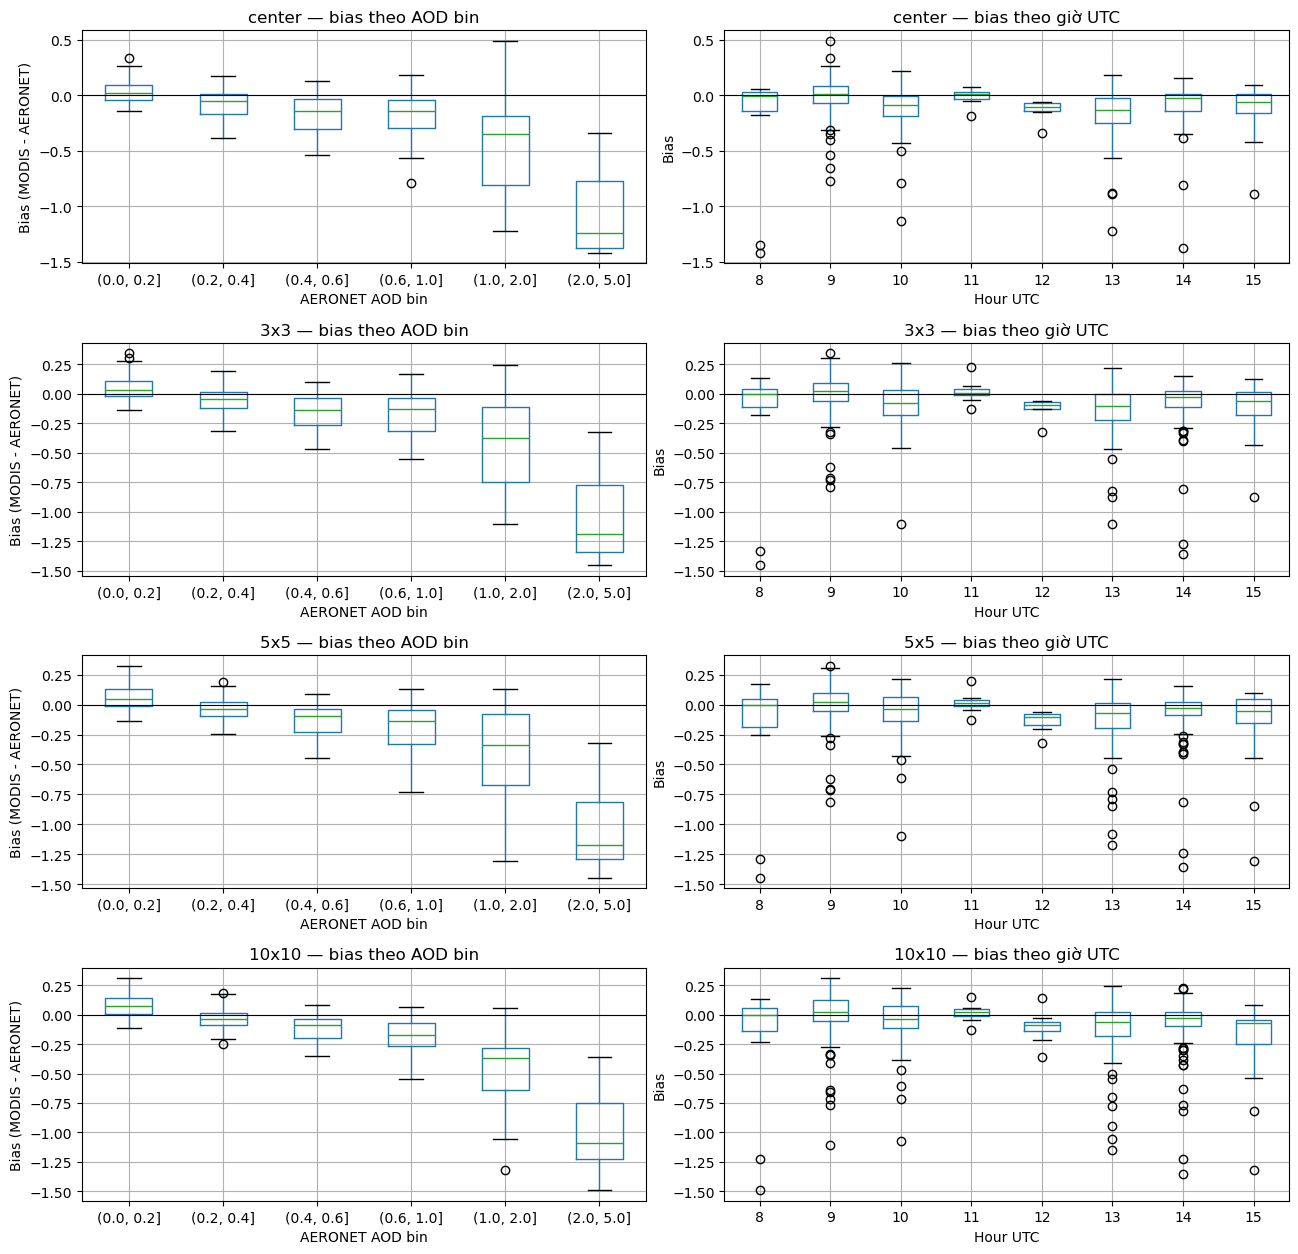

In [9]:
if len(pairs):
    pairs = pairs.copy()
    pairs['bias']     = pairs.sat_mean - pairs.aer_mean
    pairs['hour_utc'] = pd.to_datetime(pairs.ts).dt.hour
    pairs['aod_bin']  = pd.cut(pairs.aer_mean,
                               bins=[0, 0.2, 0.4, 0.6, 1.0, 2.0, 5.0])

    fig, axes = plt.subplots(len(VERSIONS), 2,
                             figsize=(13, 3.2 * len(VERSIONS)), squeeze=False)
    for i, v in enumerate(VERSIONS):
        sub = pairs[pairs['version'] == v]
        sub.boxplot(column='bias', by='aod_bin', ax=axes[i, 0])
        axes[i, 0].axhline(0, color='k', lw=0.8)
        axes[i, 0].set_title(f'{v} — bias theo AOD bin')
        axes[i, 0].set_xlabel('AERONET AOD bin'); axes[i, 0].set_ylabel('Bias (MODIS - AERONET)')

        sub.boxplot(column='bias', by='hour_utc', ax=axes[i, 1])
        axes[i, 1].axhline(0, color='k', lw=0.8)
        axes[i, 1].set_title(f'{v} — bias theo giờ UTC')
        axes[i, 1].set_xlabel('Hour UTC'); axes[i, 1].set_ylabel('Bias')
    plt.suptitle(''); fig.tight_layout(); plt.show()

### So sánh MBE / RMSE theo phiên bản (bar chart)

Cách trực quan nhất để chọn window size.

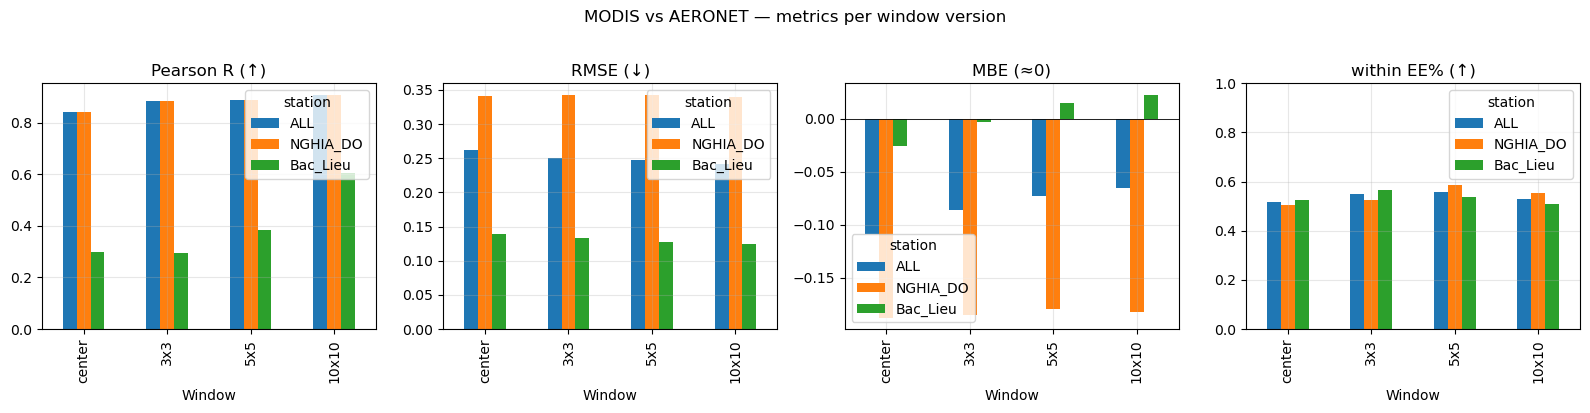

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric, title in zip(
    axes,
    ['R', 'RMSE', 'MBE', 'within_EE'],
    ['Pearson R (↑)', 'RMSE (↓)', 'MBE (≈0)', 'within EE% (↑)'],
):
    d = metrics.pivot(index='version', columns='station', values=metric).loc[VERSIONS]
    d.plot.bar(ax=ax)
    ax.set_title(title); ax.grid(alpha=0.3); ax.set_xlabel('Window')
    if metric == 'within_EE':
        ax.set_ylim(0, 1)
    ax.axhline(0, color='k', lw=0.6)
fig.suptitle('MODIS vs AERONET — metrics per window version', y=1.02)
fig.tight_layout(); plt.show()

## 7. Density scatter theo giờ UTC — mỗi version một figure

Mỗi panel là một giờ UTC. Mật độ điểm tô màu bằng Gaussian KDE.


=== MODIS window: center ===


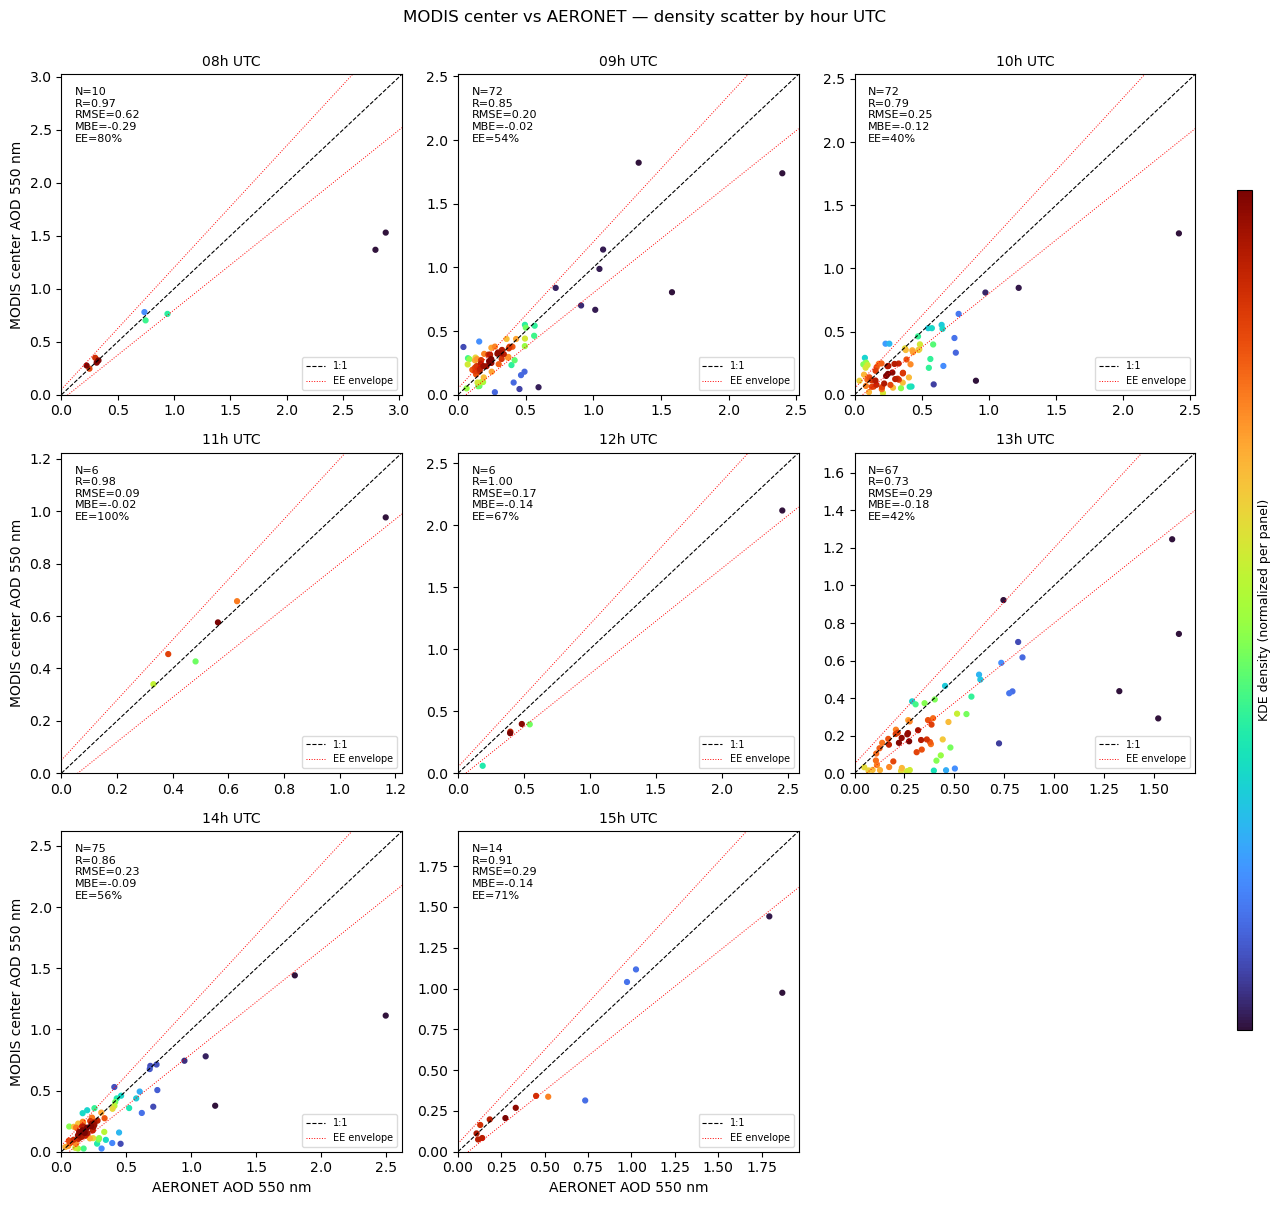


=== MODIS window: 3x3 ===


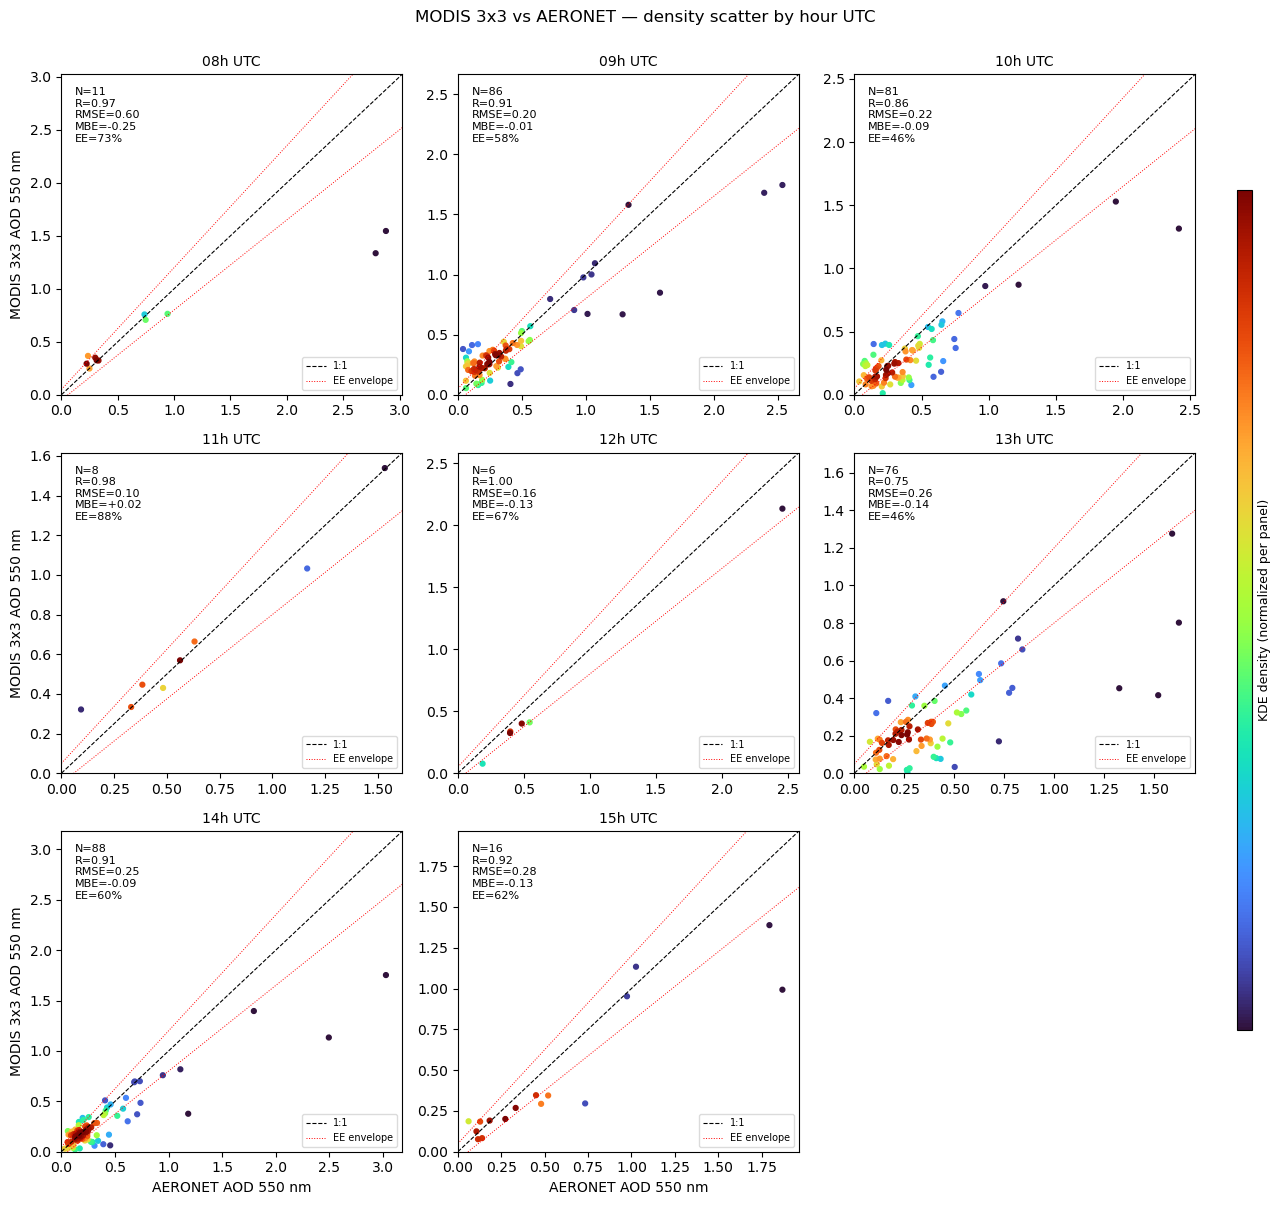


=== MODIS window: 5x5 ===


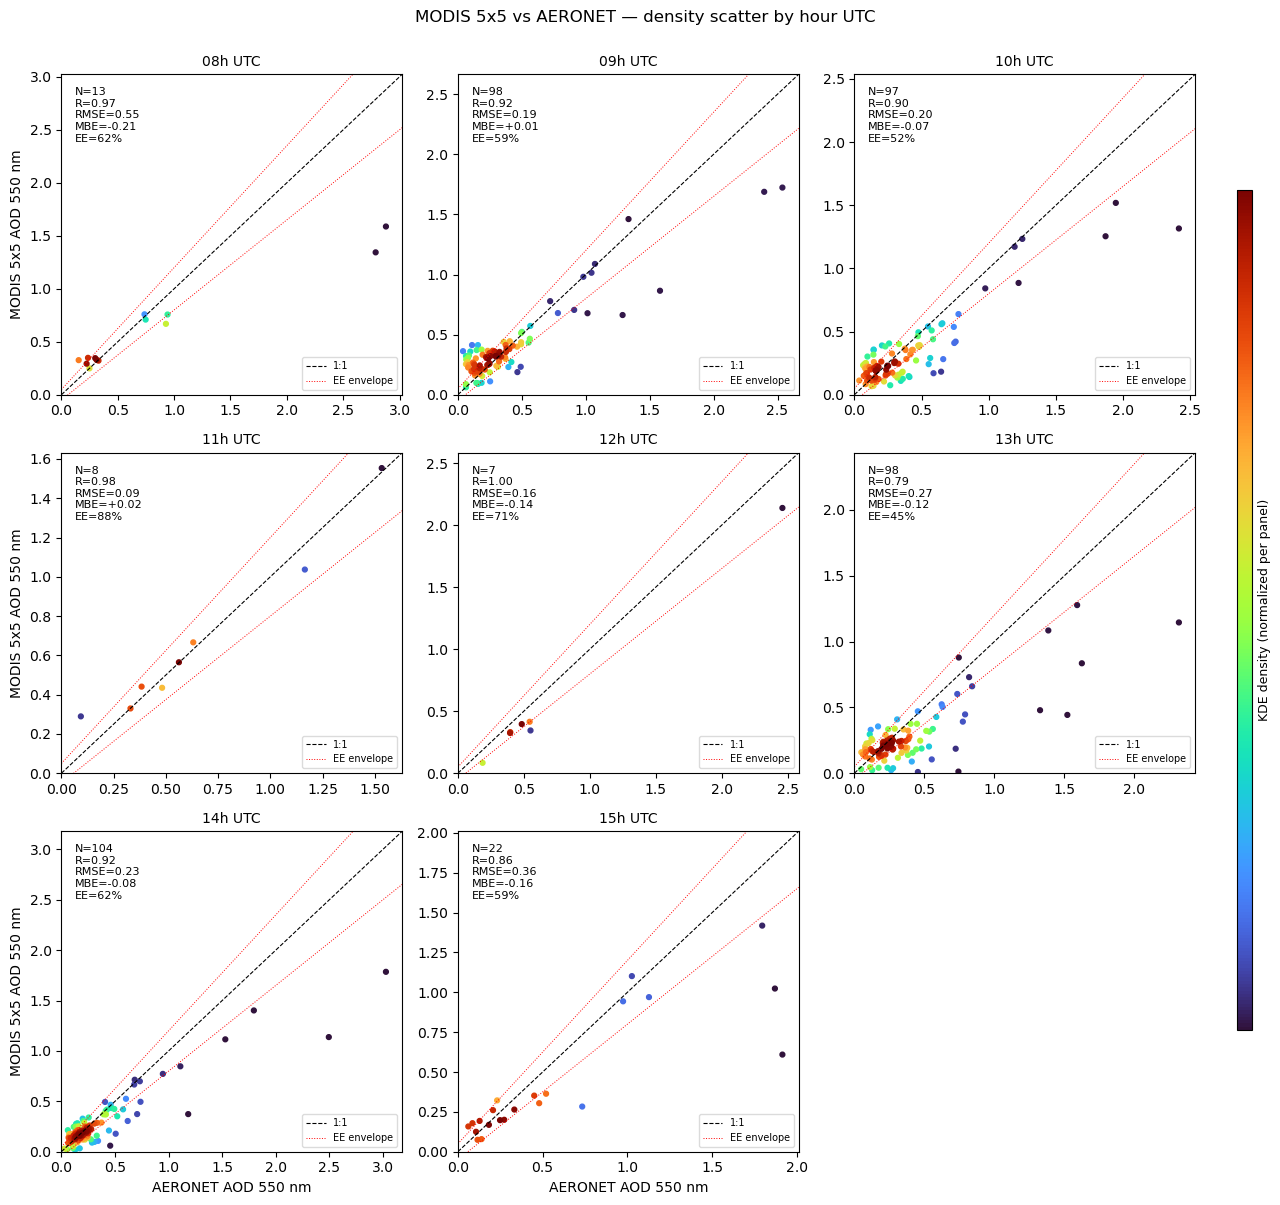


=== MODIS window: 10x10 ===


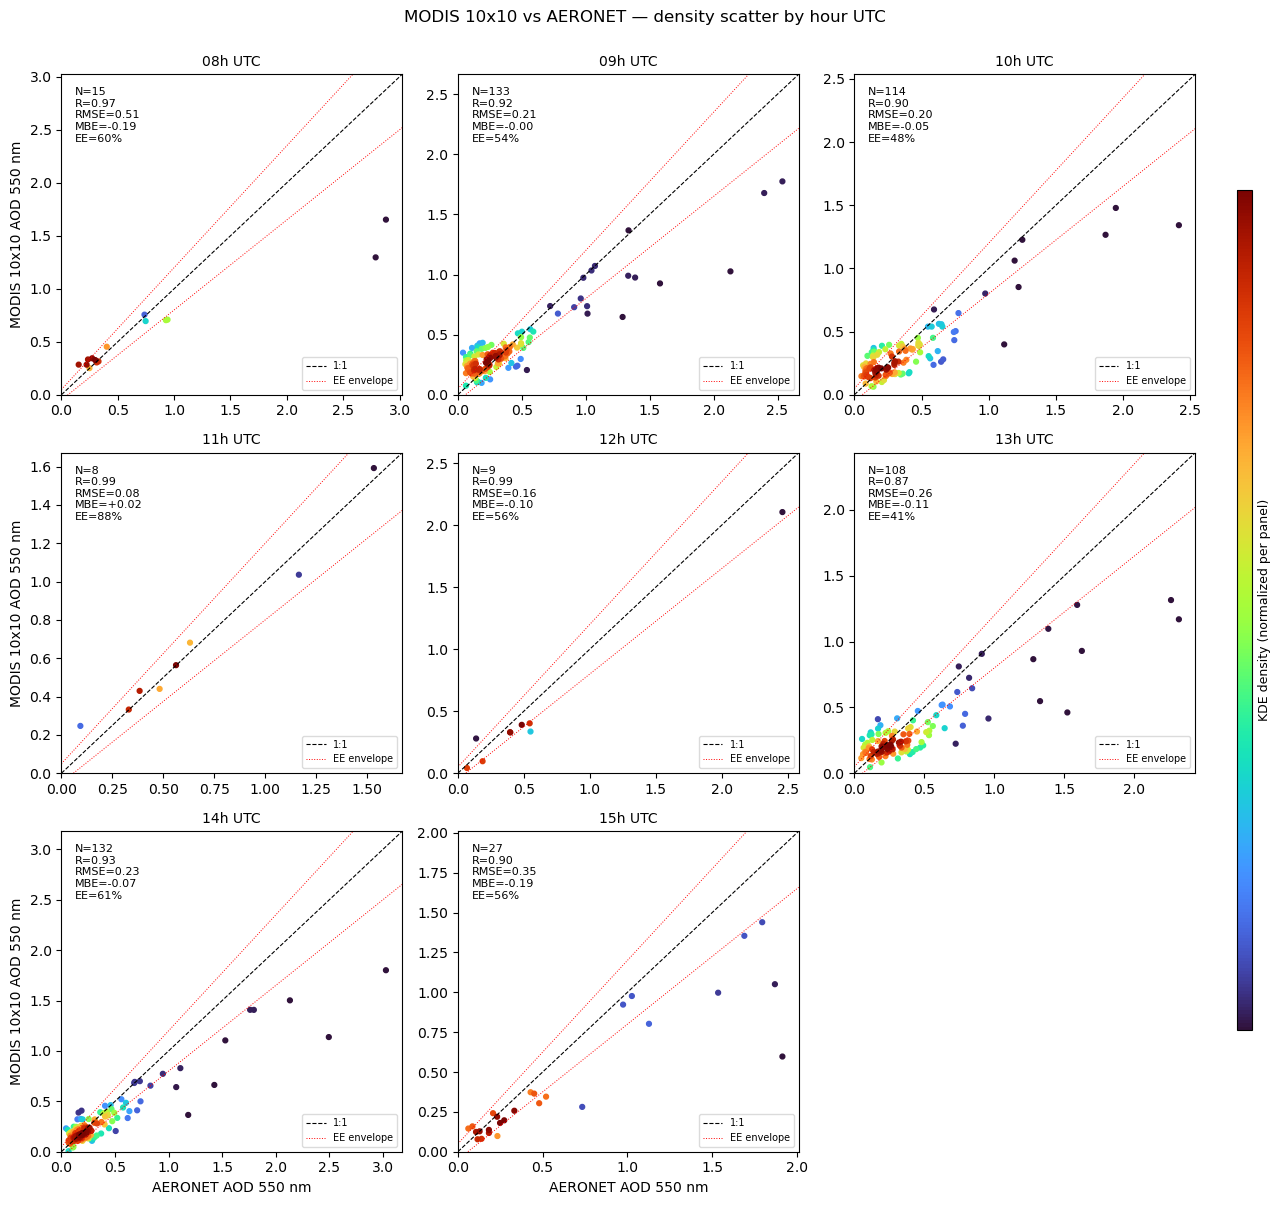

In [11]:
MIN_N_HOUR = 5
NCOLS_HOUR = 3

def _density_panel(ax, x, y, label):
    n = len(x)
    sc = None
    if n == 0:
        ax.set_title(f'{label} - empty'); ax.set_axis_off(); return sc
    if n >= 5:
        try:
            xy = np.vstack([x, y])
            z = stats.gaussian_kde(xy)(xy)
            order = z.argsort()
            x, y, z = x[order], y[order], z[order]
            sc = ax.scatter(x, y, c=z, s=12, cmap='turbo')
        except Exception:
            ax.scatter(x, y, s=12, alpha=0.5)
    else:
        ax.scatter(x, y, s=12, alpha=0.5)
    lim = max(float(x.max()), float(y.max()), 0.1) * 1.05
    grid = np.linspace(0, lim, 100)
    l_11, = ax.plot(grid, grid, 'k--', lw=0.8, label='1:1')
    l_ee, = ax.plot(grid, grid + (0.05 + 0.15 * grid), 'r:', lw=0.7, label='EE envelope')
    ax.plot(grid, grid - (0.05 + 0.15 * grid), 'r:', lw=0.7)
    if n >= 2:
        r, _ = stats.pearsonr(x, y)
        rmse = float(np.sqrt(np.mean((y - x) ** 2)))
        mbe  = float(np.mean(y - x))
        ee   = 0.05 + 0.15 * x
        within = float(np.mean((y - x >= -ee) & (y - x <= ee)))
        txt = (f"N={n}\nR={r:.2f}\nRMSE={rmse:.2f}\n"
               f"MBE={mbe:+.2f}\nEE={within*100:.0f}%")
        ax.text(0.04, 0.96, txt, transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(label, fontsize=10)
    ax.legend(handles=[l_11, l_ee], loc='lower right', fontsize=7, framealpha=0.7)
    return sc

def density_scatter_by_hour(df, sat_col='sat_mean', sensor_label='MODIS'):
    sub = df.dropna(subset=['aer_mean', sat_col]).copy()
    sub['hour_utc'] = pd.to_datetime(sub.ts).dt.hour
    counts = sub.groupby('hour_utc').size()
    hours = sorted(counts[counts >= MIN_N_HOUR].index.tolist())
    if not hours:
        print(f'{sensor_label}: no hour has >= {MIN_N_HOUR} pairs'); return
    nrows = int(np.ceil(len(hours) / NCOLS_HOUR))
    fig, axes = plt.subplots(nrows, NCOLS_HOUR,
                             figsize=(4 * NCOLS_HOUR + 1, 4 * nrows), squeeze=False)
    last_sc = None
    for i, h in enumerate(hours):
        ax = axes[i // NCOLS_HOUR, i % NCOLS_HOUR]
        g = sub[sub.hour_utc == h]
        sc = _density_panel(ax, g['aer_mean'].values, g[sat_col].values, f'{h:02d}h UTC')
        if sc is not None:
            last_sc = sc
        if i // NCOLS_HOUR == nrows - 1:
            ax.set_xlabel('AERONET AOD 550 nm')
        if i % NCOLS_HOUR == 0:
            ax.set_ylabel(f'{sensor_label} AOD 550 nm')
    for j in range(len(hours), nrows * NCOLS_HOUR):
        axes[j // NCOLS_HOUR, j % NCOLS_HOUR].set_axis_off()
    fig.suptitle(f'{sensor_label} vs AERONET — density scatter by hour UTC',
                 y=1.0, fontsize=12)
    fig.tight_layout(rect=[0, 0, 0.94, 1.0])
    if last_sc is not None:
        cax = fig.add_axes([0.955, 0.15, 0.012, 0.7])
        cbar = fig.colorbar(last_sc, cax=cax)
        cbar.set_label('KDE density (normalized per panel)', fontsize=9)
        cbar.set_ticks([])
    plt.show()

for v in VERSIONS:
    print(f'\n=== MODIS window: {v} ===')
    density_scatter_by_hour(pairs[pairs['version'] == v],
                            sensor_label=f'MODIS {v}')

## 8. Lưu collocated pairs

File này có cột `version ∈ {center, 3x3, 5x5, 10x10}` nên một dòng MODIS overpass có thể xuất hiện ≤ 4 lần (mỗi version một dòng).

In [12]:
out = Path('/home/slow_data/Air_Quality/MODIS_MCD19A2/aeronet_modis_pairs.csv')
pairs.to_csv(out, index=False)
print('Saved:', out, '-', len(pairs), 'rows')

Saved: /home/slow_data/Air_Quality/MODIS_MCD19A2/aeronet_modis_pairs.csv - 1687 rows
